<a href="https://colab.research.google.com/github/ryan-merser/ST554-BigData/blob/main/ST554_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST554: Analysis of Big Data Homework 6

Ryan Mersereau

## Part 1: More Practice Querying a Database

### 1. Continuing with the Lahman sqlite database
Let's once again connect to the database and look at all the tables using `read_sql()`

In [ ]:
import sqlite3
import pandas as pd

con = sqlite3.connect("lahman_1871-2022.sqlite")

# Query to return all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
tables

,name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


### 2. Table of Hall of Fame Pitchers

Let's construct a table of hall of fame pitchers that gives the playerID and their total (sum) for GS, G, W, L, IPOuts, CG, SHO, and SV columns.

In [ ]:
query = """
SELECT DISTINCT p.playerID, p.GS, p.G, p.W, p.L, p.IPouts, p.CG, p.SHO, p.SV
FROM Pitching p
INNER JOIN HallOfFame hof ON p.playerID = hof.playerID
WHERE hof.inducted = 'Y'
"""

hof_pitchers = pd.read_sql(query, con)

# Summing across variables
hof_pitchers_totals = hof_pitchers.groupby('playerID')[['GS', 'G', 'W', 'L', 'IPouts', 'CG', 'SHO', 'SV']].sum().reset_index()

hof_pitchers_totals

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11
104,wrighge01,0,3,0,1,15,0,0,0
105,wrighha01,8,36,4,4,301,0,0,14
106,wynnea01,612,691,300,244,13692,290,49,15


We see some hall of fame players have very few or poor pitching statistics, so we can infer these players may have got in the hall of fame for their batting, managing, or coaching achievements

### 3. Batting Stats for HOF Pitchers

For all of the hall of fame pitchers, lets create a table of their batting statistics. Namely, the
playerID and their total (sum) for AB, R, H, HR, RBI, BB, and SO.


In [ ]:
query = """
SELECT b.playerID, b.AB, b.R, b.H, b.HR, b.RBI, b.BB, b.SO
FROM Batting b
INNER JOIN HallOfFame hof ON b.playerID = hof.playerID
INNER JOIN Pitching p ON b.playerID = p.playerID
WHERE hof.inducted = 'Y'
"""

hof_pitcher_batting = pd.read_sql(query, con)

#Sum all batting stats for each pitcher in hof_pitchers
hof_pitcher_batting_totals = hof_pitcher_batting.groupby('playerID')[['AB', 'R', 'H', 'HR', 'RBI', 'BB', 'SO']].sum().reset_index()

hof_pitcher_batting_totals

,playerID,AB,R,H,HR,RBI,BB,SO
0,alexape01,38010,3234,7938,231,3423.0,1617,5796.0
1,ansonca01,20562,3998,6870,194,4150.0,1968,660.0
2,becklja01,9551,1603,2938,87,1581.0,616,526.0
3,bendech01,18352,1632,3888,96,1856.0,1200,2288.0
4,blylebe01,10824,456,1416,0,600.0,120,4632.0
...,...,...,...,...,...,...,...,...
103,willivi01,19409,1391,3224,13,1092.0,1053,2587.0
104,wrighge01,5746,1330,1732,22,652.0,136,238.0
105,wrighha01,3252,732,896,16,452.0,148,56.0
106,wynnea01,39192,3128,8395,391,3979.0,3243,7590.0


### Joining both tables

Finally, lets join the previous two tables together by pitcher

In [ ]:
hof_pitchers_combined = pd.merge(hof_pitchers_totals, hof_pitcher_batting_totals,
                                  on='playerID',
                                  how='inner')

hof_pitchers_combined

,playerID,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
0,alexape01,599,696,373,208,15570,437,90,32,38010,3234,7938,231,3423.0,1617,5796.0
1,ansonca01,0,3,0,1,12,0,0,1,20562,3998,6870,194,4150.0,1968,660.0
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581.0,616,526.0
3,bendech01,334,459,212,127,9051,255,40,34,18352,1632,3888,96,1856.0,1200,2288.0
4,blylebe01,685,692,287,250,14910,242,60,0,10824,456,1416,0,600.0,120,4632.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11,19409,1391,3224,13,1092.0,1053,2587.0
104,wrighge01,0,3,0,1,15,0,0,0,5746,1330,1732,22,652.0,136,238.0
105,wrighha01,8,36,4,4,301,0,0,14,3252,732,896,16,452.0,148,56.0
106,wynnea01,612,691,300,244,13692,290,49,15,39192,3128,8395,391,3979.0,3243,7590.0


## Part 2: Messing with Classes

### Estimating slope simulation

Previously, we used a loop to repeatedly do simulations around the estimate of a sample
slope.

The code used is below:

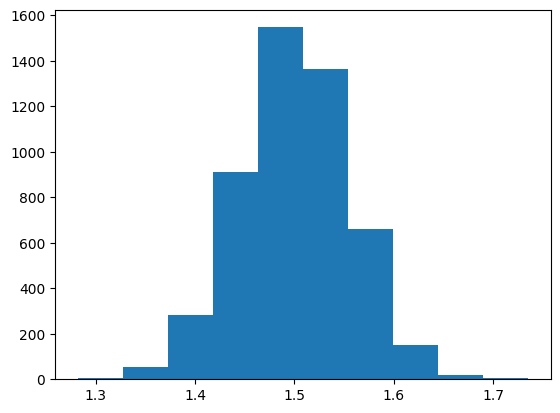

In [ ]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)

#prepare for the LR fit
reg = linear_model.LinearRegression()
#Create a reg object

#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))
for i in range(5000):
  #create the 'responses' modeled from the line plus a random deviation
  y = beta_0 + beta_1*x + rng.standard_normal(n)
  #find the least squares solutions and store them
  fit = reg.fit(x.reshape(-1, 1), y)
  beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

In [ ]:
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

np.float64(0.0038)

### Simulating using a class

Instead of doing this, let's design a Python class that encapsulates the simulation
of the sampling distribution of the slope estimator!

We'll do this in JupyterHub and create a .py file output!

Testing code below:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

# Creating class for SLR slope simulation
class SLR_slope_simulator:
    """
    Simulates the sampling distribution of the slope estimator
    in a SLR model:
        y = beta_0 + beta_1 * x + epsilon,  epsilon ~ N(0, sigma^2)
    """

# Initialize class with parameter arguments
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        """
        Initialize the simulator
        Parameters
        ----------
        beta_0 : float  – true intercept
        beta_1 : float  – true slope
        x      : array  – fixed predictor values
        sigma  : float  – standard deviation of the error term
        seed   : int    – random seed for reproducibility
        """
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.x      = np.array(x)
        self.sigma  = sigma
        self.n      = len(x)
        self.rng    = default_rng(seed)
        self.slopes = []

    # Generate_data method
    def generate_data(self):
        """
        Generate one synthetic dataset from the true SLR model.

        Returns
        -------
        x : ndarray  – the fixed predictor values
        y : ndarray  – simulated responses
        """
        y = self.beta_0 + self.beta_1 * self.x + self.rng.normal(loc=0, scale=self.sigma, size=self.n)
        return self.x, y

    # fit_slope method
    def fit_slope(self, x, y):
        """
        Fit an SLR model to (x, y) and return the estimated slope.

        Parameters
        ----------
        x : array-like
        y : array-like

        Returns
        -------
        float – OLS slope estimate (beta_1 hat)
        """
        reg = linear_model.LinearRegression()
        reg.fit(np.array(x).reshape(-1, 1), np.array(y))
        return reg.coef_[0]

    # run_simulations method
    def run_simulations(self, num_simulations):
        """
        Run the simulation loop and store all slope estimates.

        Parameters
        ----------
        num_simulations : int – number of repetitions

        Side-effect
        -----------
        Replaces self.slopes with an ndarray of length num_simulations.
        """
        slope_estimates = np.zeros(num_simulations)
        for i in range(num_simulations):
            x, y = self.generate_data()
            slope_estimates[i] = self.fit_slope(x, y)
        self.slopes = slope_estimates

    # plot_sampling_distribution method
    def plot_sampling_distribution(self):
        """
        Plot a histogram of the simulated slope estimates.
        Prints an error message if run_simulations() has not been called yet.
        """
        if len(self.slopes) == 0:
            print("Error: run_simulations() must be called first before plotting.")
            return

        plt.figure(figsize=(8, 5))
        plt.hist(self.slopes, bins=40, edgecolor="black", color="steelblue", alpha=0.8)
        plt.axvline(self.beta_1, color="red", linestyle="--", linewidth=1.5,
                    label=f"True β₁ = {self.beta_1}")
        plt.xlabel("Estimated Slope (β̂₁)", fontsize=13)
        plt.ylabel("Frequency", fontsize=13)
        plt.title("Simulated Sampling Distribution of the Slope Estimator", fontsize=14)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # find_prob method
    def find_prob(self, value, sided):
        """
        Approximate a probability from the simulated slope distribution.

        Parameters
        ----------
        value  : float  – reference value
        sided  : str    – one of {"above", "below", "two-sided"}

        Returns
        -------
        float – estimated probability (or None if simulations not run)
        """
        if len(self.slopes) == 0:
            print("Error: run_simulations() must be called first before computing probabilities.")
            return None

        sided = sided.lower()

        if sided == "above":
            prob = np.mean(self.slopes > value)
            print(f"P(β̂₁ > {value}) ≈ {prob:.4f}")
        elif sided == "below":
            prob = np.mean(self.slopes < value)
            print(f"P(β̂₁ < {value}) ≈ {prob:.4f}")
        elif sided == "two-sided":
            prob = np.mean(np.abs(self.slopes) > value)
            print(f"P(|β̂₁| > {value}) ≈ {prob:.4f}")
        else:
            raise ValueError("sided must be 'above', 'below', or 'two-sided'.")

        return prob

--- Calling plot_sampling_distribution() before run_simulations() ---
Error: run_simulations() must be called first before plotting.

--- Running 10,000 simulations ---


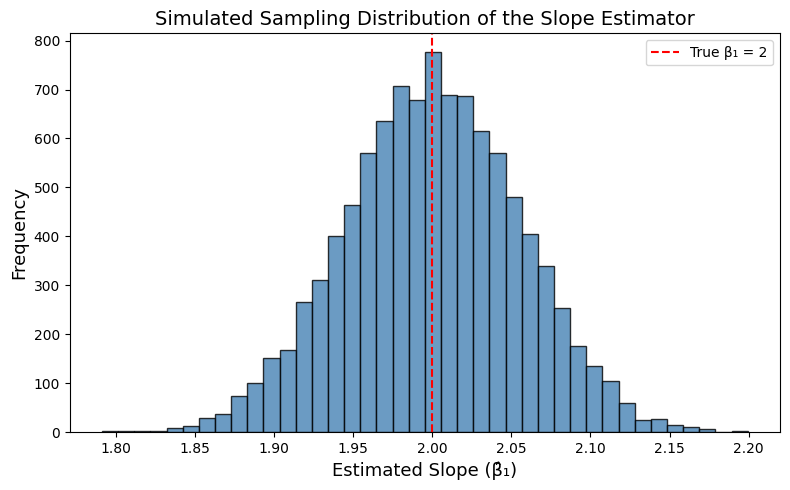


--- Two-sided probability for value = 2.1 ---
P(|β̂₁| > 2.1) ≈ 0.0352

--- First 10 simulated slope values (sim.slopes[:10]) ---
[2.0239168  1.99560551 2.04249093 1.96489641 2.01114235 1.98626121
 2.03443803 2.08981268 2.01691868 1.91179937]

Total slopes stored: 10000


In [ ]:
# Demo

if __name__ == "__main__":

    # Create an instance
    x_vals = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)

    sim = SLR_slope_simulator(
        beta_0=12,
        beta_1=2,
        x=x_vals,
        sigma=1,
        seed=10
    )

    # Call plot_sampling_distribution BEFORE run_simulations — should print error
    print("--- Calling plot_sampling_distribution() before run_simulations() ---")
    sim.plot_sampling_distribution()

    # Run 10,000 simulations
    print("\n--- Running 10,000 simulations ---")
    sim.run_simulations(10_000)

    # Plot the sampling distribution
    sim.plot_sampling_distribution()

    # Two-sided probability of |β̂₁| > 2.1
    print("\n--- Two-sided probability for value = 2.1 ---")
    sim.find_prob(value=2.1, sided="two-sided")

    # Print the first 10 simulated slopes (full array is sim.slopes)
    print("\n--- First 10 simulated slope values (sim.slopes[:10]) ---")
    print(sim.slopes[:10])

    print(f"\nTotal slopes stored: {len(sim.slopes)}")